In [1]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.3

Found existing installation: protobuf 6.33.0
Uninstalling protobuf-6.33.0:
  Successfully uninstalled protobuf-6.33.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; pyth

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns
import torch
import transformers

from datasets import Dataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    TrainingArguments,
    Trainer,
    logging
)

from tqdm.auto import tqdm

2025-12-02 10:26:25.535921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764671185.738349      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764671185.792619      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    macro_f1 = f1_score(labels, predictions, average="weighted")
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average="weighted")
    recall = recall_score(labels, predictions, average="weighted")

    return {
        "macro_f1": macro_f1,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    }

The function below was used to create a training .parquet set of 25000 sample and a validation .parquet set of 2500 samples. The files are saved locally and uploaded as dataset inputs.

In [4]:
def stratified_sample(
    df: pd.DataFrame,
    size: int
):
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=size,
        random_state=42
    )

    for sample_idx, _ in splitter.split(df, df["label"]):
        return df.iloc[sample_idx].copy()

In [5]:
base_path_training_validation = "/kaggle/input/training-validation-samples-third"
base_path_test = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_b"

training_path = base_path_training_validation + "/training_sample_set.parquet"
validation_path = base_path_training_validation + "/validation_sample_set.parquet"
test_path = base_path_test + "/task_b_test_set_sample.parquet"

training_df = pd.read_parquet(training_path)
validation_df = pd.read_parquet(validation_path)
test_df = pd.read_parquet(test_path)

In [6]:
pretrained_model = "microsoft/codebert-base"

In [7]:
tokenizer = AutoTokenizer.from_pretrained(pretrained_model)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

The functions below preprocess code samples and erase the comments.

In [8]:
def clean_c_like_hard(code: str) -> str:
    if not isinstance(code, str):
        return ""
    lines = code.split('\n')
    cleaned_lines = []
    for line in lines:
        if any(x in line for x in ['//', '/*', '*/', '#']) or re.match(r'^\s*\*', line):
            continue
        cleaned_lines.append(line)
    code = '\n'.join(cleaned_lines)
    return re.sub(r'\s+', ' ', code).strip()

def clean_python(code: str) -> str:
    if not isinstance(code, str):
        return ""
    code = re.sub(r'"""[\s\S]*?"""', '', code, flags=re.MULTILINE)
    code = re.sub(r"'''[\s\S]*?'''", '', code, flags=re.MULTILINE)
    lines = []
    for line in code.split('\n'):
        if re.match(r'^\s*#', line):
            continue
        if '#' in line:
            line = line.split('#')[0]
        lines.append(line)
    code = '\n'.join(lines)
    return re.sub(r'\s+', ' ', code).strip()

def clean_php(code: str) -> str:
    if not isinstance(code, str):
        return ""
    lines = code.split('\n')
    cleaned_lines = []
    for line in lines:
        if any(x in line for x in ['//', '/*', '*/', '#']) or re.match(r'^\s*\*', line):
            continue
        cleaned_lines.append(line)
    code = '\n'.join(cleaned_lines)
    return re.sub(r'\s+', ' ', code).strip()

def clean_code(code: str, language: str) -> str:
    lang = language.lower() if isinstance(language, str) else ""
    if lang == "python":
        return clean_python(code)
    elif lang in ["c", "cpp", "c++", "csharp", "java", "go", "js", "javascript"]:
        return clean_c_like_hard(code)
    elif lang == "php":
        return clean_php(code)
    else:
        return code.strip()

In [9]:
def preprocess_function(examples: pd.DataFrame):
    cleaned_code = []
    for code, language in zip(examples["code"], examples["language"]):
        cleaned = clean_code(code, language)
        cleaned_code.append(cleaned)

    return tokenizer(cleaned_code, truncation=True, max_length=256)

In [10]:
training_dataset = Dataset.from_pandas(training_df)
validation_dataset = Dataset.from_pandas(validation_df)
test_dataset = Dataset.from_pandas(test_df)

training_tokenized_set = training_dataset.map(preprocess_function, batched=True)
validation_tokenized_set = validation_dataset.map(preprocess_function, batched=True)
test_tokenized_set = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [11]:
id2label = {
    0: "Human",
    1: "deepseek-ai/DeepSeek-V3-0324",
    2: "Qwen/Qwen2.5-Coder-7B-Instruct",
    3: "01-ai/Yi-Coder-9B-Chat",
    4: "bigcode/starcoder",
    5: "gemma-3n-e4b-it",
    6: "microsoft/phi-2",
    7: "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    8: "ibm-granite/granite-3.2-2b-instruct",
    9: "mistralai/Devstral-Small-2505",
    10: "GPT-4o-mini"
}

label2id = {
    "Human": 0,
    "deepseek-ai/DeepSeek-V3-0324": 1,
    "Qwen/Qwen2.5-Coder-7B-Instruct": 2,
    "01-ai/Yi-Coder-9B-Chat": 3,
    "bigcode/starcoder": 4,
    "gemma-3n-e4b-it": 5,
    "microsoft/phi-2": 6,
    "meta-llama/Llama-3.3-70B-Instruct-Turbo": 7,
    "ibm-granite/granite-3.2-2b-instruct": 8,
    "mistralai/Devstral-Small-2505": 9,
    "GPT-4o-mini": 10
}

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model,
    num_labels=11,
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("\nRunning on device:", device)


Running on device: cuda


In [14]:
logging.set_verbosity_info()

In [15]:
class TrainingProgressCallback(transformers.TrainerCallback):
    def on_step_end(self, args, state, control, **kwargs):
        if state.is_local_process_zero:
            tqdm.write(f"Step {state.global_step}/{state.max_steps}")

In [16]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [17]:
training_args = TrainingArguments(
    output_dir="UniXCoder_model",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    metric_for_best_model="macro_f1",
    load_best_model_at_end=True,
    save_total_limit=1,
    logging_steps=1,
    fp16=True,
    disable_tqdm=False,
    ddp_find_unused_parameters=False,
    dataloader_num_workers=0,
    no_cuda=False,
    report_to=[]
)

PyTorch: setting up devices


In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=training_tokenized_set,
    eval_dataset=validation_tokenized_set,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2),
               TrainingProgressCallback()]
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Using auto half precision backend


In [19]:
trainer.train(resume_from_checkpoint=False)

The following columns in the Training set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 25,000
  Num Epochs = 3
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 16
  Total train batch size (w. parallel, distributed & accumulation) = 32
  Gradient Accumulation steps = 2
  Total optimization steps = 2,346
  Number of trainable parameters = 124,654,091
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 1/2346


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Precision,Recall
1,0.232600,0.416280,0.866899,0.892400,0.846520,0.892400
2,0.180500,0.415829,0.875106,0.886800,0.871161,0.886800
3,0.389100,0.418486,0.874402,0.885200,0.871836,0.885200


Step 2/2346
Step 3/2346
Step 4/2346
Step 5/2346
Step 6/2346
Step 7/2346
Step 8/2346
Step 9/2346
Step 10/2346
Step 11/2346
Step 12/2346
Step 13/2346
Step 14/2346
Step 15/2346
Step 16/2346
Step 17/2346
Step 18/2346
Step 19/2346
Step 20/2346
Step 21/2346
Step 22/2346
Step 23/2346
Step 24/2346
Step 25/2346
Step 26/2346
Step 27/2346
Step 28/2346
Step 29/2346
Step 30/2346
Step 31/2346
Step 32/2346
Step 33/2346
Step 34/2346
Step 35/2346
Step 36/2346
Step 37/2346
Step 38/2346
Step 39/2346
Step 40/2346
Step 41/2346
Step 42/2346
Step 43/2346
Step 44/2346
Step 45/2346
Step 46/2346
Step 47/2346
Step 48/2346
Step 49/2346
Step 50/2346
Step 51/2346
Step 52/2346
Step 53/2346
Step 54/2346
Step 55/2346
Step 56/2346
Step 57/2346
Step 58/2346
Step 59/2346
Step 60/2346
Step 61/2346
Step 62/2346
Step 63/2346
Step 64/2346
Step 65/2346
Step 66/2346
Step 67/2346
Step 68/2346
Step 69/2346
Step 70/2346
Step 71/2346
Step 72/2346
Step 73/2346
Step 74/2346
Step 75/2346
Step 76/2346
Step 77/2346
Step 78/2346
Step 79

The following columns in the Evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2500
  Batch size = 16
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Saving model checkpoint to UniXCoder_model/checkpoint-782
Configuration saved in UniXCoder_model/checkpoint-782/config.json
Model weights saved in UniXCoder_model/checkpoint-782/model.safetensors
tokenizer config file saved in UniXCoder_model/checkpoint-782/tokenizer_config.json
Special tokens file saved in UniXCoder_mode

Step 783/2346
Step 784/2346
Step 785/2346
Step 786/2346
Step 787/2346
Step 788/2346
Step 789/2346
Step 790/2346
Step 791/2346
Step 792/2346
Step 793/2346
Step 794/2346
Step 795/2346
Step 796/2346
Step 797/2346
Step 798/2346
Step 799/2346
Step 800/2346
Step 801/2346
Step 802/2346
Step 803/2346
Step 804/2346
Step 805/2346
Step 806/2346
Step 807/2346
Step 808/2346
Step 809/2346
Step 810/2346
Step 811/2346
Step 812/2346
Step 813/2346
Step 814/2346
Step 815/2346
Step 816/2346
Step 817/2346
Step 818/2346
Step 819/2346
Step 820/2346
Step 821/2346
Step 822/2346
Step 823/2346
Step 824/2346
Step 825/2346
Step 826/2346
Step 827/2346
Step 828/2346
Step 829/2346
Step 830/2346
Step 831/2346
Step 832/2346
Step 833/2346
Step 834/2346
Step 835/2346
Step 836/2346
Step 837/2346
Step 838/2346
Step 839/2346
Step 840/2346
Step 841/2346
Step 842/2346
Step 843/2346
Step 844/2346
Step 845/2346
Step 846/2346
Step 847/2346
Step 848/2346
Step 849/2346
Step 850/2346
Step 851/2346
Step 852/2346
Step 853/2346
Step 8

The following columns in the Evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2500
  Batch size = 16
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Saving model checkpoint to UniXCoder_model/checkpoint-1564
Configuration saved in UniXCoder_model/checkpoint-1564/config.json
Model weights saved in UniXCoder_model/checkpoint-1564/model.safetensors
tokenizer config file saved in UniXCoder_model/checkpoint-1564/tokenizer_config.json
Special tokens file saved in UniXCoder_

Step 1565/2346
Step 1566/2346
Step 1567/2346
Step 1568/2346
Step 1569/2346
Step 1570/2346
Step 1571/2346
Step 1572/2346
Step 1573/2346
Step 1574/2346
Step 1575/2346
Step 1576/2346
Step 1577/2346
Step 1578/2346
Step 1579/2346
Step 1580/2346
Step 1581/2346
Step 1582/2346
Step 1583/2346
Step 1584/2346
Step 1585/2346
Step 1586/2346
Step 1587/2346
Step 1588/2346
Step 1589/2346
Step 1590/2346
Step 1591/2346
Step 1592/2346
Step 1593/2346
Step 1594/2346
Step 1595/2346
Step 1596/2346
Step 1597/2346
Step 1598/2346
Step 1599/2346
Step 1600/2346
Step 1601/2346
Step 1602/2346
Step 1603/2346
Step 1604/2346
Step 1605/2346
Step 1606/2346
Step 1607/2346
Step 1608/2346
Step 1609/2346
Step 1610/2346
Step 1611/2346
Step 1612/2346
Step 1613/2346
Step 1614/2346
Step 1615/2346
Step 1616/2346
Step 1617/2346
Step 1618/2346
Step 1619/2346
Step 1620/2346
Step 1621/2346
Step 1622/2346
Step 1623/2346
Step 1624/2346
Step 1625/2346
Step 1626/2346
Step 1627/2346
Step 1628/2346
Step 1629/2346
Step 1630/2346
Step 1631/

The following columns in the Evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2500
  Batch size = 16
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Saving model checkpoint to UniXCoder_model/checkpoint-2346
Configuration saved in UniXCoder_model/checkpoint-2346/config.json
Model weights saved in UniXCoder_model/checkpoint-2346/model.safetensors
tokenizer config file saved in UniXCoder_model/checkpoint-2346/tokenizer_config.json
Special tokens file saved in UniXCoder_

TrainOutput(global_step=2346, training_loss=0.43071069164961445, metrics={'train_runtime': 2374.3043, 'train_samples_per_second': 31.588, 'train_steps_per_second': 0.988, 'total_flos': 9867322086156768.0, 'train_loss': 0.43071069164961445, 'epoch': 3.0})

The following columns in the Evaluation set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 1000
  Batch size = 16
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
The following columns in the test set don't have a corresponding argument in `RobertaForSequenceClassification.forward` and have been ignored: generator, language, code. If generator, language, code are not expected by `RobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 1000
  Batch size = 16


Test results: {'eval_loss': 1.3747812509536743, 'eval_macro_f1': 0.5462361367699342, 'eval_accuracy': 0.579, 'eval_precision': 0.5312335675094133, 'eval_recall': 0.579, 'eval_runtime': 10.456, 'eval_samples_per_second': 95.638, 'eval_steps_per_second': 6.025, 'epoch': 3.0}


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


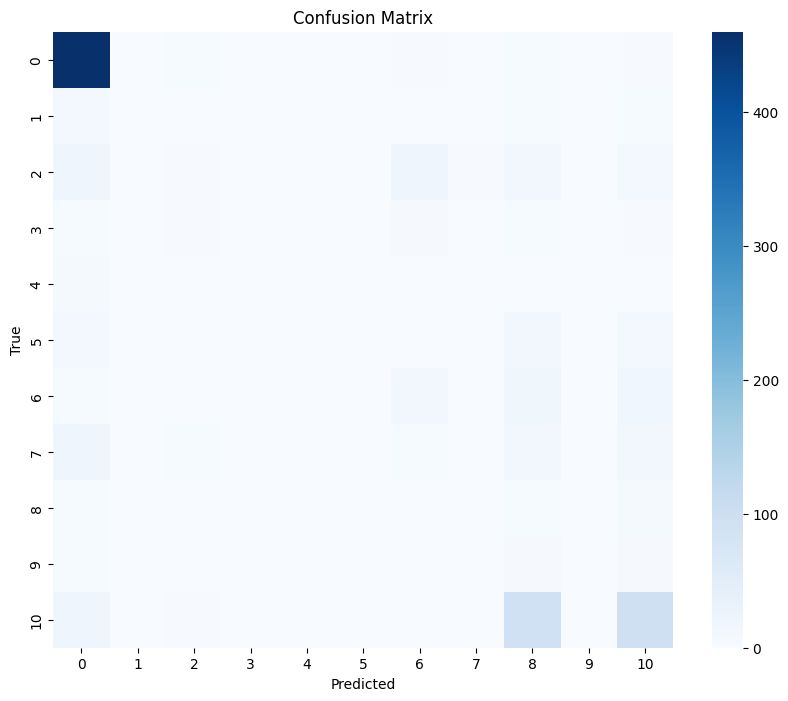

In [20]:
test_results = trainer.evaluate(test_tokenized_set)
print("Test results:", test_results)

predictions = trainer.predict(test_tokenized_set)
logits = predictions.predictions
labels = predictions.label_ids

predicted_labels = np.argmax(logits, axis=1)

cm = confusion_matrix(labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

output_df = test_tokenized_set.to_pandas()
output_df["predicted_label"] = predicted_labels
output_df.to_csv("test_predictions.csv", index=False)